In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df = pd.read_csv('C:/Users/Carlsson Arlt/VS Code/customer-chrun-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
print(f"Spalten: {df.columns.tolist()}")
df.head()

Shape: (7043, 21)
Spalten: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print(df.dtypes)

print(df.isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Mo

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


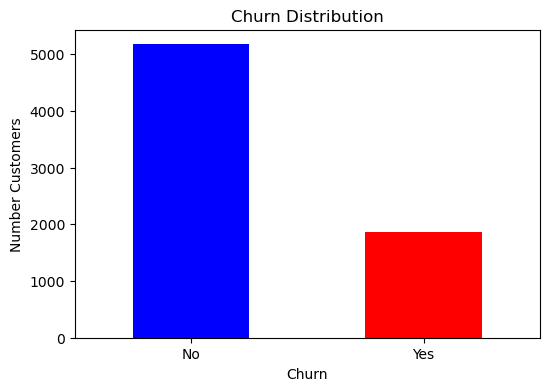

In [ ]:
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number Customers')
plt.xticks(rotation=0)
plt.show()

In [ ]:
col_an = df.select_dtypes(include=['object','str']).columns.tolist()
col_an.remove('customerID')
print(f"Categorial columns: {col_an}")

for col in col_an:
    print(f"\n{col}: {df[col].unique()}")


Categorial columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport: <StringArr

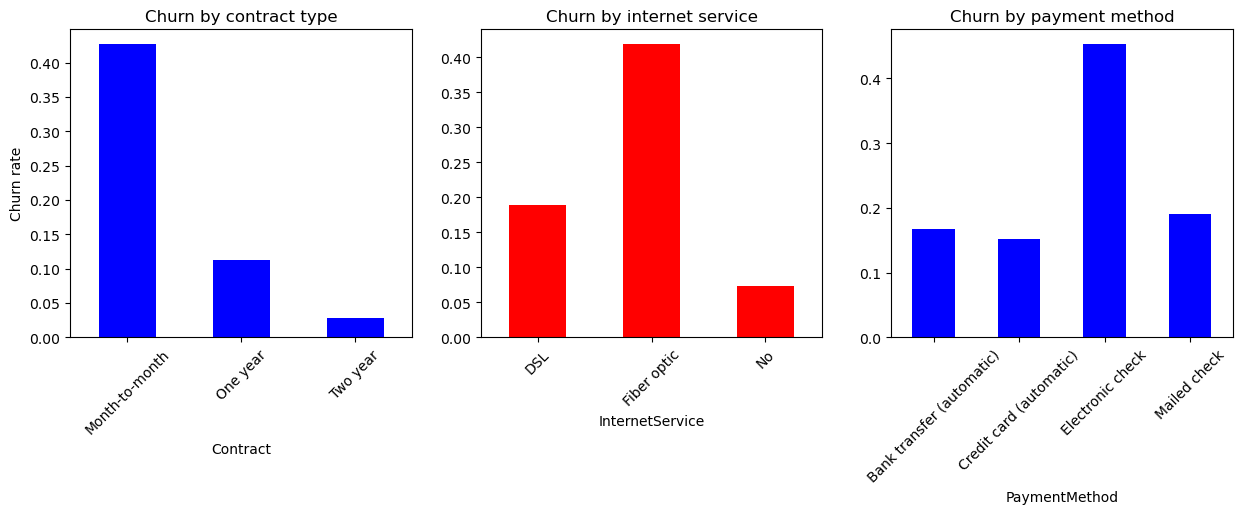

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'].plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Churn by contract type')
axes[0].set_ylabel('Churn rate')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()['Yes'].plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('Churn by internet service')
axes[1].tick_params(axis='x', rotation=45)

df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()['Yes'].plot(kind='bar', ax=axes[2], color='blue')
axes[2].set_title('Churn by payment method')
axes[2].tick_params(axis='x', rotation=45)

plt.show()



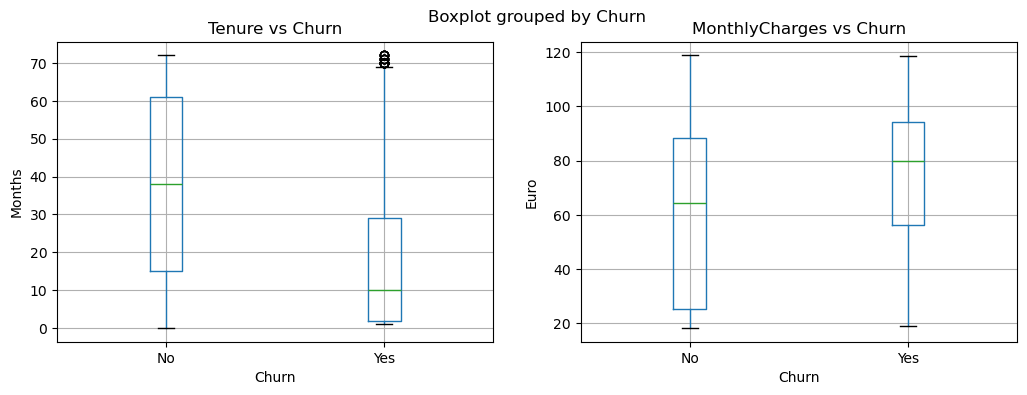

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

df.boxplot(column='tenure', by='Churn', ax=axes[0])
axes[0].set_title('Tenure vs Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Months')

df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('MonthlyCharges vs Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Euro')

plt.show()

In [ ]:
print("=== EDA Summary ===")
print(f"Total customers: {len(df)}")
print(f"Churn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")
print(f"\nKey Findings:")
print("1. Month-to-month customers churn 10x more than two-year contract customers")
print("2. Fiber optic customers have the highest churn rate (42%)")
print("3. Electronic check customers have the highest churn rate (45%)")
print("4. TotalCharges needs to be converted from str to float")


=== EDA Summary ===
Total customers: 7043
Churn Rate: 26.54%

Key Findings:
1. Month-to-month customers churn 10x more than two-year contract customers
2. Fiber optic customers have the highest churn rate (42%)
3. Electronic check customers have the highest churn rate (45%)
4. TotalCharges needs to be converted from str to float
